# TS1:"Sintesis y operaciones de señales"
## Alumno: Suarez Lucila

Para comenzar el trabajo practico se nos pidio sintetizar:
1. Señal sinusoidal de 2Khz que tenga al menos 10 puntos por periodo.
2. Misma señal con 2W de potencia media y desfasada en π/2.
3. Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.
4. Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W.
5. Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50%.
Utilizando siempre N=1000 muestras.
Luego, para cada señal se nos pidio visualizar el modulo de la transformada de Fourrier. 

En primer lugar se declararon las variables globales y los muestreos que se usaron en el desarrollo del codigo (como el numero de muestras N, la frecuencia de la senoidal f0 y la frecuencia de muestreo fs)

In [17]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.signal as sig

N=1000
f0=2000#(Hz)frecuencia de la señal
Puntos_Per=10
fs=Puntos_Per*f0

Posteriormente, se implementaron dos funciones que fueron fundamentales para la ejecutacion del Tp. Por un lado, tenemos "mi_funcion-sen", que es la misma funcion que se uso en la TS anterior; por otro lado, se desarrollo la funcion "modulo_Trans_Fourrier", que sirvio para optimizar el calculo de la FFT. En ella, se normalizo por el numero de muestras N y la alineacion del espectro mediante 'fftshift'.


In [18]:
def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    tt=np.arange(N)/fs #se mide en segundos
    xx = vmax * np.sin( 2 * np.pi * ff * tt + ph ) #valores de la senoidal
    #tt=np.arange(N)/fs #se mide en segundos
    
    return(tt, xx)
def modulo_Trans_Fourrier(signal, N, fs):
                         
    frec = np.fft.fftfreq(N, 1/fs) #asigna a cada muestra de la FFT su valor de frecuencia real en Hz
    fft_total = np.fft.fft(signal)
    frec = np.fft.fftshift(frec) #ordena los N asignados a cada frecuencia de menor a mayor
    mod=np.fft.fftshift(np.abs(fft_total)/N)

    return (frec,mod)

Para el primer punto, se implemento el siguiente codigo:


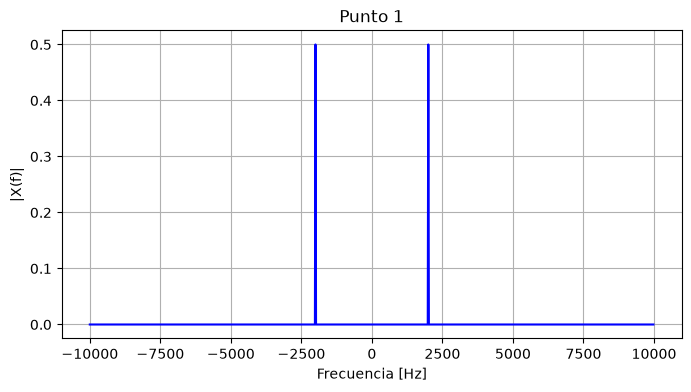

In [19]:
vmax=1 #mi amplitud max
dc=0
ph=0
nn=np.arange(N)
tt, x1 = mi_funcion_sen( vmax = vmax, dc = dc, ff = f0, nn=N, fs=fs)
frec, mod1 = modulo_Trans_Fourrier(x1, N, fs)

plt.figure(figsize=(8, 4))
plt.plot(frec, mod1, 'b')
plt.title("Punto 1")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.show()

Para el segundo punto, se implemento el siguiente codigo:

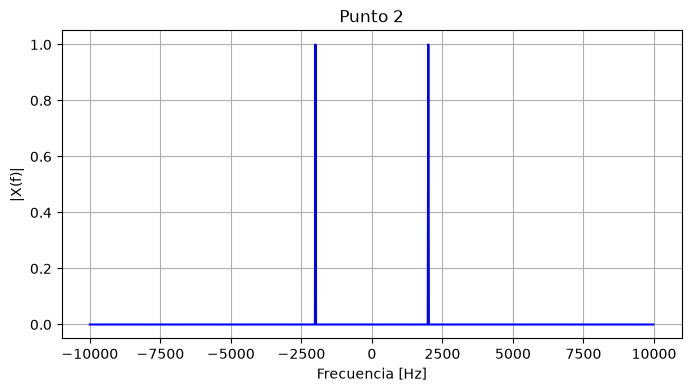

In [20]:
tt, x2 = mi_funcion_sen( vmax = 2, dc = dc, ff = f0, ph=np.pi/2, nn=N, fs=fs)
frec, mod2 = modulo_Trans_Fourrier(x2, N, fs)

plt.figure(figsize=(8, 4))
plt.plot(frec, mod2, 'b')
plt.title("Punto 2")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.show()

Para los dos puntos se grafico la FFT, normalizada en las N muestras (|X(f)|) vs la frecuencia de la señal ([Hz]). Al comparar dichos graficos se puede ver como al aumentar la potencia media (que en el codigo es la amplitud maxima) a 2W, la señal llega a valores mas altos de magnitud. En cambio, con el desfasaje (π/2) no altera la magnitud, si no, que modifica la fase de la señal. 

En esta otra parte del tp, se comparo a la FFT con otros 2 tipos de señales. Una siendo una secuencia de ruido distribuida normalmente y la otra uniformemente. 

Secuencia de ruido distribuida normalmente:

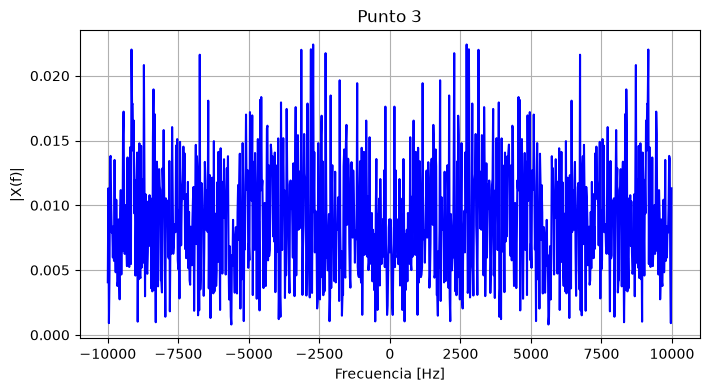

In [21]:
DC=0#V, esparnza o valor medio 
v=0.1#(W)varianza
dv=np.sqrt(v)#desvio estandar 
nq=np.random.normal(DC,dv, N)#(ruido)
frec, mod3 = modulo_Trans_Fourrier(nq, N, fs)

plt.figure(figsize=(8, 4))
plt.plot(frec, mod3, 'b')
plt.title("Punto 3")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.show()

Secuencia de ruido distribuida uniformemente:

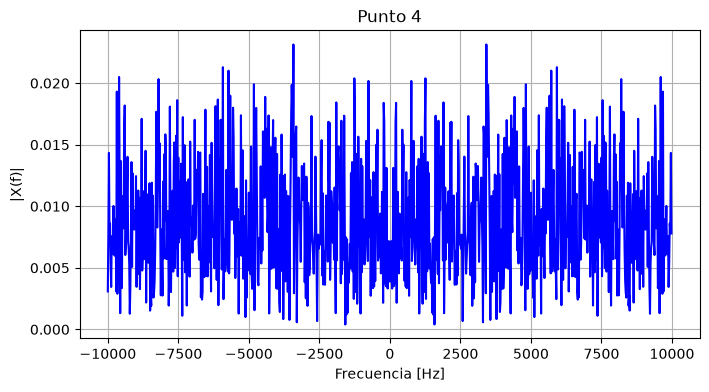

In [22]:
DC=0#V, esparnza o valor medio 
v=0.1#(W)varianza
a=np.sqrt(3*v)
nq=np.random.uniform(-a,a,N)#(ruido) seria la amplitud limite, es el pico maximo que alcanzara el ruido uniforme
frec, mod4 = modulo_Trans_Fourrier(nq, N, fs)

plt.figure(figsize=(8, 4))
plt.plot(frec, mod4, 'b')
plt.title("Punto 4")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.show()

A pesar de sus diferencias debido a sus distribuciones, por tener el mismo valor medio y varianza sus graficos son similares. 

Por ultimo, se realizo un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50%.

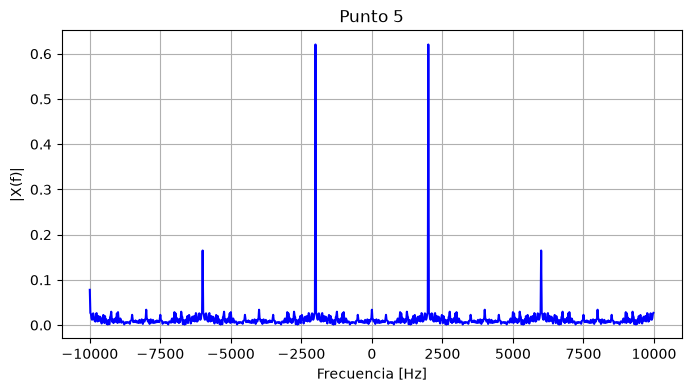

In [23]:
amp5=1#(V)amplitud del pico de onda
tt=np.arange(N)/fs#crea el vector de tiempos en segundos. Define el instante exacto de cadda muestra temporal
x5=amp5*sig.square(2*np.pi*f0*tt, duty=0.5)#genera la onda cuadrada en el tiempo
frec, mod5 = modulo_Trans_Fourrier(x5, N, fs)

plt.figure(figsize=(8, 4))
plt.plot(frec, mod5, 'b')
plt.title("Punto 5")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)
plt.show()

A diferencia de la señal senoidal, el modulo de la FFT evidencia la precensia de multiples componentes frecuenciales. En el grafico se muestra como a medida que aumenta la frecuencia, los picos de la magnitud disminuyen.